# Importing Libraries

In [47]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("deep")

In [48]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/ML Projects/Project07_Sales_Forecasting_Using_ML/E-commerce_Sales_Data(2014-17).csv", encoding="cp1252")

# Data Cleaning & Standardization

In [49]:
df.duplicated().sum()
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [50]:
df.columns= df.columns.str.lower().str.replace(" ","_")

#Feature Engineering

In [51]:
df["order_date"]=pd.to_datetime(df["order_date"]) #converting in object to date-time
df["months"] = df["order_date"].dt.month #Month feature
df["years"] = df["order_date"].dt.year #Year feature

In [52]:
#Creating aggregated data frame for feature engineering & modeling
df_monthly = (
    df.groupby(["years", "months"])["sales"]
      .sum()
      .reset_index()
)

In [53]:
#Creating a date column for Sorting chronologically, train/test split by time, plotting forecasts and future predictions
df_monthly["date"] = pd.to_datetime(
    dict(
        year=df_monthly["years"],
        month=df_monthly["months"],
        day=1
    )
)

df_monthly = df_monthly.sort_values("date")

In [54]:
#Sorting chronologically for arranged features
df_monthly = df_monthly.sort_values("date")

In [55]:
#Checking the shape of data-frame for data validation
df_monthly.shape

(48, 4)

In [56]:
#Creating a monthly sales lag feature
df_monthly["sales_lag_1"] = df_monthly["sales"].shift(1)

df_monthly["sales_lag_2"] = df_monthly["sales"].shift(2)

df_monthly["sales_lag_3"] = df_monthly["sales"].shift(3)

In [57]:
#Creating a monthly average rolling features
df_monthly["rolling_3_month_avg"] = df_monthly["sales"].shift(1).rolling(window=3).mean()

df_monthly["rolling_6_month_avg"] = df_monthly["sales"].shift(1).rolling(window=6).mean()

In [58]:
#Dropping the Null(nan) value we get from lag and rolling features
df_monthly.dropna(inplace=True)
df_monthly.head()

,years,months,sales,date,sales_lag_1,sales_lag_2,sales_lag_3,rolling_3_month_avg,rolling_6_month_avg
6,2014,7,33946.3930,2014-07-01,34595.1276,23648.2870,28295.3450,28846.253200,26831.092600
7,2014,8,27909.4685,2014-08-01,33946.3930,34595.1276,23648.2870,30729.935867,30116.008933
8,2014,9,81777.3508,2014-09-01,27909.4685,33946.3930,34595.1276,32150.329700,34014.271683
9,2014,10,31453.3930,2014-10-01,81777.3508,27909.4685,33946.3930,47877.737433,38361.995317
10,2014,11,78628.7167,2014-11-01,31453.3930,81777.3508,27909.4685,47046.737433,38888.336650


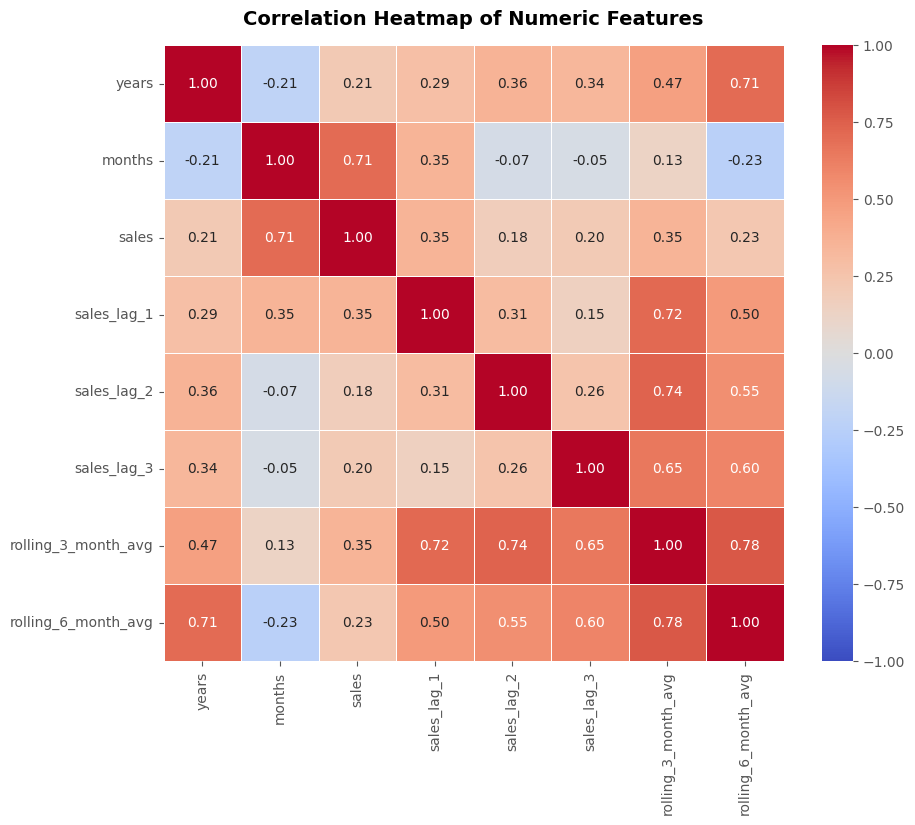

In [59]:
#Checking the correlation between the new features and the sales(target)
numeric_df = df_monthly.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=14, pad=15, fontweight="bold")
plt.show()

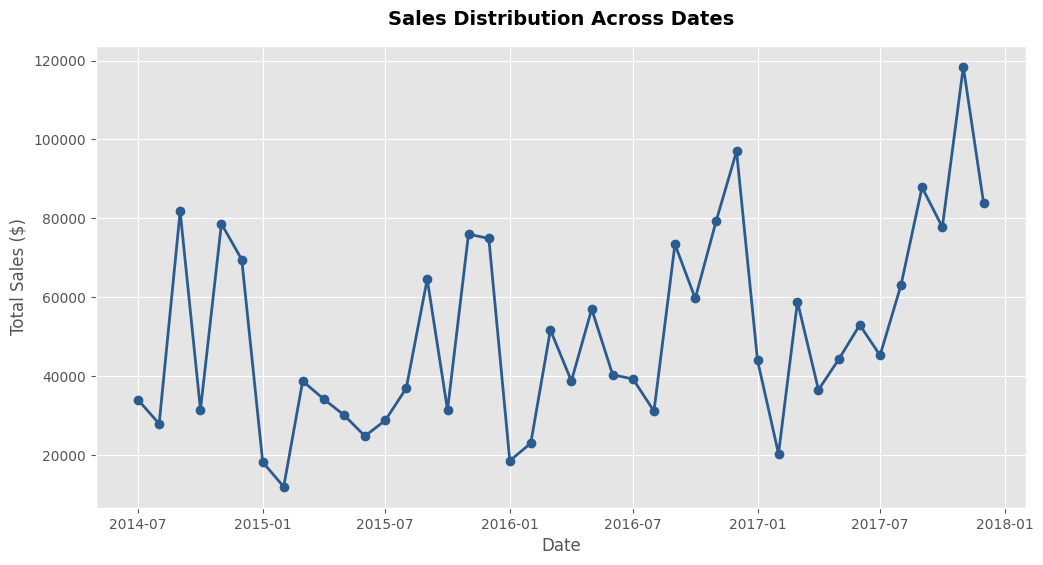

In [60]:
#Checking Sales distribution across dates

plt.figure(figsize=(12, 6))

plt.plot(df_monthly["date"], df_monthly["sales"], marker="o", color="#2b5c8f", linewidth=2)
plt.title("Sales Distribution Across Dates", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")

plt.show()

#Encoding & Scaling

In [61]:
#Converting years and months columns into int and str style respectively
df_monthly['years'] = df_monthly['years'].astype(int)
df_monthly['months'] = df_monthly['months'].astype(str)

#Splitting target sales and dropping date columns
y = df_monthly['sales']
X_raw = df_monthly.drop(columns=['sales', 'date'])

#Encoding the months column
X_encoded = pd.get_dummies(
    X_raw,
    columns=['months'],
    drop_first=True
)

In [62]:
#Splitting the into X_train, X_test, y_train,& y_test
train_size = int(len(X_encoded) * 0.8)

X_train = X_encoded[:train_size]
X_test = X_encoded[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [63]:
# Scaling the featured columns
cols_to_scale = [
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'rolling_3_month_avg',
    'rolling_6_month_avg'
]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

#Modeling

In [64]:
model = LinearRegression()
model.fit(X_train, y_train)

linear_pred = model.predict(X_test)

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

ridge_pred = model_ridge.predict(X_test)

model_lasso = Lasso(alpha=0.1)
model_lasso.fit(X_train, y_train)

lasso_pred = model_lasso.predict(X_test)

In [65]:
# Importing Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

### Model Evaluation

In [66]:
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print(f"MAE : {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAPE: {mean_absolute_percentage_error(y_true, y_pred)*100:.2f}%")
    print(f"R²  : {r2_score(y_true, y_pred):.4f}")

evaluate(y_test,linear_pred,"Linear Regression")
evaluate(y_test, ridge_pred, "Ridge Regression")
evaluate(y_test, lasso_pred, "Lasso Regression")


Linear Regression
MAE : 12054.68
RMSE: 14026.52
MAPE: 18.62%
R²  : 0.6841

Ridge Regression
MAE : 15820.27
RMSE: 20300.11
MAPE: 21.28%
R²  : 0.3384

Lasso Regression
MAE : 12054.03
RMSE: 14029.06
MAPE: 18.62%
R²  : 0.6840


###Actual vs Predicted Plot

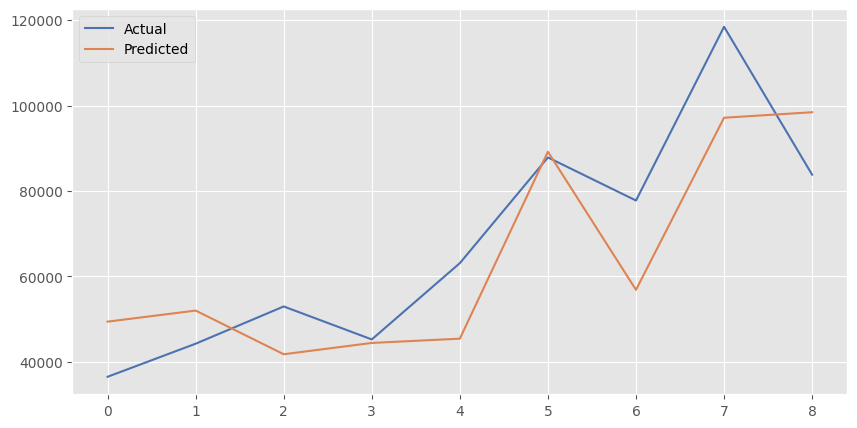

In [68]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(linear_pred, label="Predicted")
plt.legend()
plt.show()

####Insight
- The model has learned useful patterns but cannot fully capture extreme monthly fluctuations.

###Feature Importance / Coefficient Analysis

In [69]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
16,months_9,60064.624295
7,months_11,59038.609010
8,months_12,54675.284423
12,months_5,31096.680038
11,months_4,27678.494374
6,months_10,26296.133044
10,months_3,22917.495837
14,months_7,19601.625060
15,months_8,17548.621926
9,months_2,-16405.036905


###Insight
- The model identified strong seasonal effects, with several months contributing substantially to predicted sales. Lag and rolling features captured historical sales patterns, although their coefficients were influenced by multicollinearity.

###Residual Plot

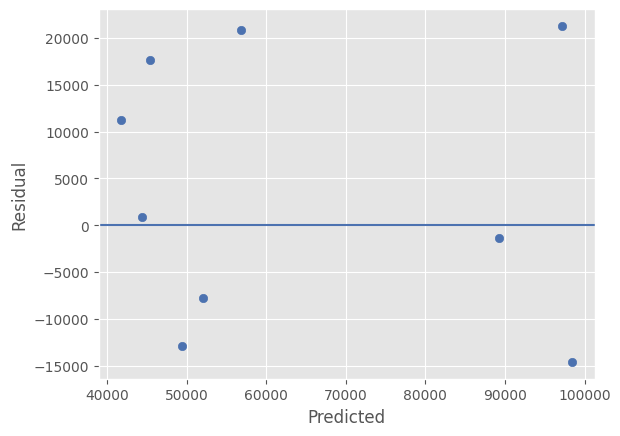

In [74]:
residuals = y_test - linear_pred

plt.scatter(linear_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

### Insights
- Residuals are distributed around zero with no obvious systematic pattern, suggesting the Linear Regression model captures the overall trend. However, some large residuals indicate difficulty in predicting extreme monthly sales fluctuations.

# Business Insights & Recommendations

### Insights
 - The business experienced long-term sales growth over the study period.
 - Monthly seasonality appears to influence sales performance.
 - The forecasting model provides a reasonable estimate of future monthly revenue and can support budgeting and inventory planning.

### Recommendation
 - Increase inventory before historically strong sales months.
 - Use monthly forecasts during budget planning.
 - Monitor months with unusually high sales spikes because the model tends to underestimate extreme peaks.
 - Collect additional variables (marketing spend, holidays, promotions) to improve forecast accuracy.